In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
torch.__version__

'2.11.0+cu128'

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
torch.manual_seed(2026)
np.random.seed(2026)

In [ ]:
class PINN(nn.Module):
    """Fully-connected network that approximates u(x)."""

    def __init__(self, hidden_layers: int = 4, neurons: int = 150):
        super().__init__()
        layers = [nn.Linear(1, neurons), nn.SiLU()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(neurons, neurons), nn.Tanh()]
        layers.append(nn.Linear(neurons, 1))
        self.net = nn.Sequential(*layers)

        # Xavier initialisation for better convergence
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [ ]:
def beam_residual(model: PINN, x: torch.Tensor, w = 4.0, L = 10.0, EI = 625e3) -> torch.Tensor:
    """
    ODE: u''(x) + u(x) = 0
    Compute residual using automatic differentiation.
    """
    x = x.requires_grad_(True)
    u = model(x)

    # First derivative
    u_x = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
    )[0]

    # Second derivative
    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
        retain_graph=True
    )[0]

    residual = u_xx + ((w * L * 0.5) * x - (w * 0.5) * (x**2)) / (625e3)          # u'' - M/EI = 0
    return residual

In [ ]:
def compute_loss(model: PINN,
                 x_col: torch.Tensor,
                 x_bc_1: torch.Tensor,
                 u_bc_1: torch.Tensor,
                 x_bc_2: torch.Tensor,
                 u_bc_2: torch.Tensor,
                 x_bc_3: torch.Tensor,
                 ux_bc_3: torch.Tensor,
                 x_bc_4: torch.Tensor,
                 ux_bc_4: torch.Tensor,
                 x_bc_5: torch.Tensor,
                 ux_bc_5: torch.Tensor,
                 lambda_bc: float):
    # Physics loss (ODE residual)
    res = beam_residual(model, x_col)
    loss_pde = torch.mean(res ** 2)

    # Dirichlet BCs
    u_pred_bc_1 = model(x_bc_1)
    loss_bc = torch.mean((u_pred_bc_1 - u_bc_1) ** 2)
    u_pred_bc_2 = model(x_bc_2)
    loss_bc += torch.mean((u_pred_bc_2 - u_bc_2) ** 2)

    # Neumann BC  →  u'(x_bc_3) = ux_bc
    x_bc_3 = x_bc_3.requires_grad_(True)
    u_bc_3 = model(x_bc_3)
    ux_3 = torch.autograd.grad(
        u_bc_3, x_bc_3,
        grad_outputs=torch.ones_like(u_bc_3),
        create_graph=True,
        retain_graph=True
    )[0]
    loss_bc += torch.mean((ux_3 - ux_bc_3) ** 2)

    x_bc_4 = x_bc_4.requires_grad_(True)
    u_bc_4 = model(x_bc_4)
    ux_4 = torch.autograd.grad(
        u_bc_4, x_bc_4,
        grad_outputs=torch.ones_like(u_bc_4),
        create_graph=True,
        retain_graph=True
    )[0]
    loss_bc += torch.mean((ux_4 - ux_bc_4) ** 2)

    x_bc_5 = x_bc_5.requires_grad_(True)
    u_bc_5 = model(x_bc_5)
    ux_5 = torch.autograd.grad(
        u_bc_5, x_bc_5,
        grad_outputs=torch.ones_like(u_bc_5),
        create_graph=True,
        retain_graph=True
    )[0]
    loss_bc += torch.mean((ux_5 - ux_bc_5) ** 2)


    total = loss_pde + lambda_bc * loss_bc
    return total, loss_pde, loss_bc

In [ ]:
def train(
    model: PINN,
    epochs: int = 40_000,
    n_collocation: int = 2000,
    lr: float = 1e-3,
    lambda_bc: float = 10.0,
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,    # ← same Adam optimizer from above
    mode     = 'min',
    patience = 1000,
    factor   = 0.5,
    min_lr   = 1e-6
)

    w  = 4.0
    L  = 10.0
    EI = 625e3
    slope = (w * (L**3)) / (24.0 * EI)

    # Boundary conditions: u(0)=0, u_x(5)=0, u(10)=0, u_x(0) = (wL^3)/24EI, u_x(10) = -(wL^3)/24EI
    x_bc_1 = torch.tensor([[0.0]], dtype=torch.float32).to(device)
    u_bc_1 = torch.tensor([[0.0]],  dtype=torch.float32).to(device)
    x_bc_2 = torch.tensor([[10.0]], dtype=torch.float32).to(device)
    u_bc_2 = torch.tensor([[0.0]],  dtype=torch.float32).to(device)
    x_bc_3 = torch.tensor([[0.0]],  dtype=torch.float32).to(device)
    ux_bc_3  = torch.tensor([[+slope]],  dtype=torch.float32).to(device)
    x_bc_4 = torch.tensor([[5.0]],  dtype=torch.float32).to(device)
    ux_bc_4  = torch.tensor([[0.0]],  dtype=torch.float32).to(device)
    x_bc_5 = torch.tensor([[10.0]], dtype=torch.float32).to(device)
    ux_bc_5  = torch.tensor([[(-1) * slope]],  dtype=torch.float32).to(device)

    history = {"total": [], "pde": [], "bc": []}

    for epoch in range(1, epochs + 1):
        model.train()

        # Re-sample collocation points every epoch for better generalisation
        x_col = torch.rand(n_collocation, 1, dtype=torch.float32).to(device) * 10.0

        optimizer.zero_grad()
        loss, l_pde, l_bc = compute_loss(model, x_col, x_bc_1, u_bc_1, x_bc_2, u_bc_2, x_bc_3, ux_bc_3, x_bc_4, ux_bc_4, x_bc_5, ux_bc_5,  lambda_bc)
        loss.backward()
        optimizer.step()
        scheduler.step(loss)

        history["total"].append(loss.item())
        history["pde"].append(l_pde.item())
        history["bc"].append(l_bc.item())

        if epoch % 2000 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:>6d} | "
                f"Total: {loss.item():.2e} | "
                f"PDE: {l_pde.item():.2e} | "
                f"BC: {l_bc.item():.2e}"
            )

    return history

In [ ]:
def evaluate_and_plot(model: PINN, history: dict):

    # Problem parameters
    w  = 4.0      # kN/m  - UDL
    L  = 10.0     # m     - beam length
    EI = 625e3    # kN·m² - flexural rigidity

    model.eval()
    x_test = torch.linspace(0, 10.0, 500).unsqueeze(1).to(device)

    with torch.no_grad():
        u_pred = model(x_test).cpu().numpy().flatten()

    x_np     = x_test.cpu().numpy().flatten()
    u_exact  = (w / (24 * EI)) * (x_np**4 - 2*L*x_np**3 + L**3 * x_np)
    abs_err  = np.abs(u_pred - u_exact)

    print(f"\nMax absolute error : {abs_err.max():.4e}")
    print(f"Mean absolute error: {abs_err.mean():.4e}")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle("PINN Solution of  u'' - M/EI = 0,  u(0)=u(10)=0,  u'(5) = 0", fontsize=13, fontweight="bold")

    # — Solution comparison —
    ax = axes[0]
    ax.plot(x_np, u_exact, "b-",  lw=2,   label="Exact")
    ax.plot(x_np, u_pred,  "r--", lw=2,   label="PINN prediction")
    ax.scatter([0, 10.0], [0, 0], s=80, zorder=5, color="k", label="Boundary conditions")
    ax.set_xlabel("x");  ax.set_ylabel("u(x)")
    ax.set_title("Solution");  ax.legend();  ax.grid(True, alpha=0.3)

    # — Absolute error —
    ax = axes[1]
    ax.semilogy(x_np, abs_err, "g-", lw=2)
    ax.set_xlabel("x");  ax.set_ylabel("|u_PINN − u_exact|")
    ax.set_title("Pointwise Absolute Error");  ax.grid(True, alpha=0.3)

    # — Training loss history —
    ax = axes[2]
    epochs = range(1, len(history["total"]) + 1)
    ax.semilogy(epochs, history["total"], label="Total",  lw=1.5)
    ax.semilogy(epochs, history["pde"],   label="PDE",    lw=1.5, linestyle="--")
    ax.semilogy(epochs, history["bc"],    label="BC",     lw=1.5, linestyle=":")
    ax.set_xlabel("Epoch");  ax.set_ylabel("Loss")
    ax.set_title("Training Loss");  ax.legend();  ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("/mnt/user-data/outputs/pinn_results.png", dpi=150, bbox_inches="tight")
    print("Plot saved → pinn_results.png")
    plt.show()

Epoch      1 | Total: 3.15e-02 | PDE: 6.43e-05 | BC: 3.14e-03
Epoch   2000 | Total: 5.47e-08 | PDE: 5.23e-08 | BC: 2.38e-10
Epoch   4000 | Total: 5.64e-08 | PDE: 5.62e-08 | BC: 1.92e-11
Epoch   6000 | Total: 3.50e-08 | PDE: 3.46e-08 | BC: 3.82e-11
Epoch   8000 | Total: 2.66e-08 | PDE: 2.61e-08 | BC: 4.20e-11
Epoch  10000 | Total: 1.38e-08 | PDE: 1.36e-08 | BC: 1.88e-11
Epoch  12000 | Total: 7.65e-09 | PDE: 7.58e-09 | BC: 6.74e-12
Epoch  14000 | Total: 7.47e-09 | PDE: 7.45e-09 | BC: 1.83e-12
Epoch  16000 | Total: 7.21e-09 | PDE: 7.20e-09 | BC: 1.17e-12
Epoch  18000 | Total: 6.49e-09 | PDE: 6.44e-09 | BC: 4.49e-12
Epoch  20000 | Total: 9.76e-09 | PDE: 5.87e-09 | BC: 3.89e-10
Epoch  22000 | Total: 5.18e-09 | PDE: 5.03e-09 | BC: 1.42e-11
Epoch  24000 | Total: 4.33e-09 | PDE: 4.31e-09 | BC: 2.03e-12
Epoch  26000 | Total: 3.76e-09 | PDE: 3.76e-09 | BC: 5.95e-13
Epoch  28000 | Total: 3.24e-09 | PDE: 3.24e-09 | BC: 1.45e-13
Epoch  30000 | Total: 2.74e-09 | PDE: 2.74e-09 | BC: 1.34e-13
Epoch  3

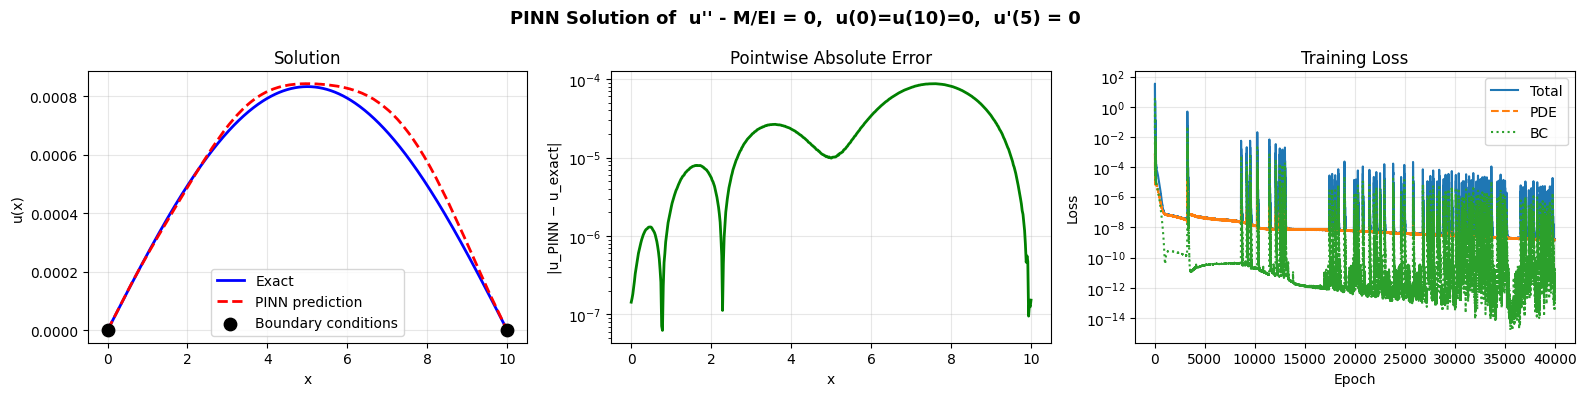

In [ ]:
import os

model = PINN().to(device)
history = train(model)

# Create the output directory if it doesn't exist
os.makedirs('/mnt/user-data/outputs/', exist_ok=True)

evaluate_and_plot(model, history)